# Analyse Exploratoire

## Import des modules

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

## Début Analyse

In [4]:
# On ouvre le jeu de données
building_consumption = pd.read_csv("../data/raw/2016_Building_Energy_Benchmarking.csv")

In [5]:
# On vérifie qu'on arrive à lire les données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [6]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

### Sens des colonnes
| Colonne                                  | Description                                                                                                                   |
|------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------|
| OSEBuildingID                            | Identifiant unique du bâtiment dans la base de données.                                                                       |
| DataYear                                 | Année de collecte des données (ici toutes en 2016).                                                                           |
| BuildingType                             | Catégorie générique du bâtiment (ex. NonResidential, SPS-District K-12, Campus).                                              |
| PrimaryPropertyType                      | Usage principal du bâtiment (ex. Hotel, Office, K-12 School, Hospital).                                                      |
| PropertyName                             | Nom commercial ou officiel du bâtiment.                                                                                       |
| Address, City, State, ZipCode            | Adresse postale complète : rue, ville, État, code postal.                                                                     |
| TaxParcelIdentificationNumber            | Numéro d’identification fiscale du lot (parcel).                                                                              |
| CouncilDistrictCode                      | Code du district municipal de Seattle.                                                                                        |
| Neighborhood                             | Quartier ou zone géographique au sein de la ville.                                                                            |
| Latitude, Longitude                      | Coordonnées géographiques en degrés décimaux (WGS 84).                                                                        |
| YearBuilt                                | Année de construction du bâtiment.                                                                                            |
| NumberofBuildings                        | Nombre d’entités bâties sous un même enregistrement.                                                                          |
| NumberofFloors                           | Nombre d’étages (incluant les sous-sols s’ils sont comptabilisés).                                                            |
| PropertyGFATotal                         | Surface brute totale (Gross Floor Area) en pieds carrés (sf).                                                                 |
| PropertyGFAParking                       | Surface du stationnement en pieds carrés.                                                                                     |
| PropertyGFABuilding(s)                   | Surface hors stationnement en pieds carrés.                                                                                   |
| ListOfAllPropertyUseTypes                | Liste des usages multiples, séparés par des virgules.                                                                         |
| LargestPropertyUseType, LargestPropertyUseTypeGFA     | Usage prédominant et sa surface (sf).                                                                                         |
| SecondLargestPropertyUseType, SecondLargestPropertyUseTypeGFA | Deuxième usage et sa surface (sf).                                                                                           |
| ThirdLargestPropertyUseType, ThirdLargestPropertyUseTypeGFA     | Troisième usage et sa surface (sf).                                                                                          |
| YearsENERGYSTARCertified                 | Nombre d’années consécutives de certification ENERGY STAR.                                                                    |
| ENERGYSTARScore                          | Score ENERGY STAR (0–100) mesurant la performance énergétique.                                                                |
| SiteEUI(kBtu/sf)                         | Consommation sur site, en milliers de BTU par pied carré et par an.                                                            |
| SiteEUIWN(kBtu/sf)                       | SiteEUI hors chauffage/climatisation.                                                                                         |
| SourceEUI(kBtu/sf)                       | Consommation à la source (pertes incluses), en kBtu/sf/an.                                                                     |
| SourceEUIWN(kBtu/sf)                     | SourceEUI hors chauffage/climatisation.                                                                                       |
| SiteEnergyUse(kBtu)                      | Consommation énergétique totale sur site, en kBtu/an.                                                                         |
| SiteEnergyUseWN(kBtu)                    | SiteEnergyUse hors chauffage/climatisation, en kBtu/an.                                                                        |
| SteamUse(kBtu)                           | Énergie vapeur utilisée, en kBtu/an.                                                                                           |
| Electricity(kWh)                         | Électricité consommée, en kWh/an.                                                                                             |
| Electricity(kBtu)                        | Électricité convertie en kBtu (1 kWh ≃ 3.412 kBtu).                                                                            |
| NaturalGas(therms)                       | Gaz naturel consommé, en therms (1 therm = 100 000 BTU).                                                                       |
| NaturalGas(kBtu)                         | Gaz naturel converti en kBtu.                                                                                                  |
| DefaultData                              | Booléen : `true` si imputé par défaut, `false` si mesuré.                                                                      |
| Comments                                 | Remarques ou annotations des agents de relevé.                                                                                 |
| ComplianceStatus                         | Statut de conformité réglementaire (Compliant / Not Compliant).                                                                |
| Outlier                                  | Indicateur d’outlier statistique (vide si non marqué).                                                                        |
| TotalGHGEmissions                        | Émissions totales de GES (CO₂-équivalent) en tonnes métriques par an.                                                         |
| GHGEmissionsIntensity                    | Intensité des émissions, en tonnes CO₂-équivalent par pied carré et par an.                                                    |


### Identification des bâtiments non résidentiels

Dans cette étape, notre objectif est d'isoler les bâtiments non destinés à l'habitation dans notre jeu de données. En effet, la mission porte sur l'étude de la consommation énergétique et des émissions de CO2 des bâtiments non résidentiels.

Pour cela, nous allons examiner les colonnes liées à l'usage principal des bâtiments, notamment `PrimaryPropertyType` et `LargestPropertyUseType`. Nous considérerons comme résidentiels tous les bâtiments dont le type principal ou l'usage le plus important correspond à des catégories résidentielles, telles que les logements multifamiliaux (Multifamily Housing), les résidences/dortoirs (Residence Hall/Dormitory) ou tout autre usage clairement résidentiel.

Nous allons donc filtrer les données pour **supprimer** les lignes correspondant aux bâtiments résidentiels, et garder uniquement les bâtiments non résidentiels pour la suite de l'analyse.

In [7]:
# Affichage de la liste exhaustive des types de bâtiments présents dans la base 
# pour identifier tous les usages et s'assurer qu'aucun type important ne soit oublié

# Liste unique des types de bâtiments dans PrimaryPropertyType (sans NaN)
primary_types = building_consumption['PrimaryPropertyType'].dropna().unique()
print("Types dans 'PrimaryPropertyType' :")
for t in sorted(primary_types):
    print(f"- {t}")

print("\n")

# Liste unique des types de bâtiments dans LargestPropertyUseType
# Supprimer NaN et convertir en string pour pouvoir trier et afficher
largest_use_types = building_consumption['LargestPropertyUseType'].dropna().astype(str).unique()
print("Types dans 'LargestPropertyUseType' :")
for t in sorted(largest_use_types):
    print(f"- {t}")

print("\n")

# Extraction unique des usages dans ListOfAllPropertyUseTypes
# Suppression des NaN, séparation, nettoyage, tri et affichage
all_use_types = building_consumption['ListOfAllPropertyUseTypes'].dropna().str.split(',').explode().str.strip().unique()
print("Tous les usages regroupés dans 'ListOfAllPropertyUseTypes' :")
for t in sorted(all_use_types):
    print(f"- {t}")

Types dans 'PrimaryPropertyType' :
- Distribution Center
- High-Rise Multifamily
- Hospital
- Hotel
- K-12 School
- Laboratory
- Large Office
- Low-Rise Multifamily
- Medical Office
- Mid-Rise Multifamily
- Mixed Use Property
- Office
- Other
- Refrigerated Warehouse
- Residence Hall
- Restaurant
- Retail Store
- Self-Storage Facility
- Senior Care Community
- Small- and Mid-Sized Office
- Supermarket / Grocery Store
- University
- Warehouse
- Worship Facility


Types dans 'LargestPropertyUseType' :
- Adult Education
- Automobile Dealership
- Bank Branch
- College/University
- Convention Center
- Courthouse
- Data Center
- Distribution Center
- Financial Office
- Fire Station
- Fitness Center/Health Club/Gym
- Food Service
- Hospital (General Medical & Surgical)
- Hotel
- K-12 School
- Laboratory
- Library
- Lifestyle Center
- Manufacturing/Industrial Plant
- Medical Office
- Movie Theater
- Multifamily Housing
- Museum
- Non-Refrigerated Warehouse
- Office
- Other
- Other - Education


### Bâtiments résidentiels à exclure

Voici la liste exhaustive des types de bâtiments résidentiels ou apparentés à exclure, d'après notre analyse :

| Type de bâtiment                | Description courte                        |
|--------------------------------|------------------------------------------|
| Single Family Home              | Maison individuelle                      |
| Multifamily Housing             | Logements collectifs                     |
| Multifamily LR (1-4)            | Logements collectifs bas étages          |
| Multifamily MR (5-9)            | Logements collectifs intermédiaires      |
| Multifamily HR (10+)            | Logements collectifs hauts étages        |
| Residence Hall / Dormitory      | Résidences étudiantes, dortoirs          |
| Other - Lodging/Residential     | Usage mixte incluant résidentiel          |

---

Cette sélection permet de retirer les bâtiments liés à l’habitation pour se concentrer uniquement sur les immeubles non résidentiels (commerces, bureaux, hôtels, établissements publics, etc.).

Cette sélection se faisant suite arbitrage humain de l'analyste (moi), l'exclusion se fera donc sur la base d'une liste créée manuellement.

In [8]:
# Liste exhaustive des types de bâtiments résidentiels à exclure
residential_types = [
    'Single Family Home',
    'Multifamily Housing',
    'Multifamily LR (1-4)',
    'Multifamily MR (5-9)',
    'Multifamily HR (10+)',
    'Residence Hall/Dormitory',
    'Other - Lodging/Residential'
]

# Copie de la base originale pour traitement (pour éviter toute suppression accidentelle)
processed = building_consumption.copy()

# Nombre de lignes avant nettoyage
nb_before = processed.shape[0]

# Identifier les lignes résidentielles à supprimer (dont l"usage principal est considéré comme résidentiel)
is_residential = (
    processed['PrimaryPropertyType'].isin(residential_types) |
    processed['LargestPropertyUseType'].isin(residential_types)
)

# Nombre de lignes à supprimer
nb_to_remove = is_residential.sum()

# Nettoyer la base en supprimant ces lignes
processed = processed[~is_residential]

# Nombre de lignes après nettoyage
nb_after = processed.shape[0]

print(f"Nombre total de lignes avant nettoyage : {nb_before}")
print(f"Nombre de lignes correspondant à des bâtiments résidentiels supprimées : {nb_to_remove}")
print(f"Nombre de lignes après nettoyage (bâtiments non résidentiels uniquement) : {nb_after}")

processed.to_csv("../data/processed/building_consumption_non-residential_cleaned.csv", index=False)

Nombre total de lignes avant nettoyage : 3376
Nombre de lignes correspondant à des bâtiments résidentiels supprimées : 1697
Nombre de lignes après nettoyage (bâtiments non résidentiels uniquement) : 1679


### Analyse des données allégées (après suppression des bâtiments résidentiels)

In [9]:
# Chargement du fichier CSV
nonresidential_building_consumption = pd.read_csv("../data/processed/building_consumption_non-residential_cleaned.csv")

### Identifier les colonnes avec beaucoup de valeurs manquantes ou constantes

In [10]:
# Pour chaque colonne, compter les valeurs manquantes
missing_values = nonresidential_building_consumption.isnull().sum()
print("Colonnes avec valeurs manquantes :\n", missing_values[missing_values > 0])

# Identifier les colonnes avec très peu de variabilité (valeurs constantes)
for col in nonresidential_building_consumption.columns:
    unique_vals = nonresidential_building_consumption[col].nunique()
    if unique_vals == 1:
        print(f"Colonne constante détectée : {col}")

Colonnes avec valeurs manquantes :
 ZipCode                              16
NumberofBuildings                     8
ListOfAllPropertyUseTypes             9
LargestPropertyUseType               20
LargestPropertyUseTypeGFA            20
SecondLargestPropertyUseType        821
SecondLargestPropertyUseTypeGFA     821
ThirdLargestPropertyUseType        1333
ThirdLargestPropertyUseTypeGFA     1333
YearsENERGYSTARCertified           1581
ENERGYSTARScore                     576
SiteEUI(kBtu/sf)                      6
SiteEUIWN(kBtu/sf)                    6
SourceEUI(kBtu/sf)                    9
SourceEUIWN(kBtu/sf)                  9
SiteEnergyUse(kBtu)                   5
SiteEnergyUseWN(kBtu)                 6
SteamUse(kBtu)                        9
Electricity(kWh)                      9
Electricity(kBtu)                     9
NaturalGas(therms)                    9
NaturalGas(kBtu)                      9
Comments                           1679
Outlier                            1663
Tota

### Choix des colonnes pour la modélisation

Dans ce projet, l'objectif est de prédire la consommation énergétique des bâtiments non résidentiels à Seattle. Pour cela, il est crucial de sélectionner judicieusement les colonnes du jeu de données afin d'optimiser la performance du modèle tout en évitant le bruit inutile.

#### Colonnes supprimées sans hésitation

Certaines colonnes sont supprimées immédiatement car elles n'apportent aucune valeur discriminante ou sont peu exploitables :

- **Comments** : colonne vide, sans données.
- **DataYear** : constante (2016) pour tous les bâtiments, sans variabilité.
- **City** et **State** : toujours "Seattle" et "WA", donc peu informatives.
- **Address** : données textuelles très spécifiques à chaque bâtiment, difficile à encoder et à généraliser.
- **TaxParcelIdentificationNumber** : identifiant unique du terrain, non pertinent pour la prédiction.
- **PropertyName** : noms uniques des bâtiments, peu exploitables en modélisation.
- **YearsENERGYSTARCertified** : le nombre d'années de certification ENERGYSTAR n'a pas d'incidence sur la consommation

#### Colonnes retenues pour analyse approfondie

D’autres colonnes, bien que nécessitant une réflexion plus poussée, sont conservées car elles apportent potentiellement une information précieuse :

- **ZipCode**, **Neighborhood**, **CouncilDistrictCode** : variables géographiques offrant une granularité locale utile à la prédiction.
- **LargestPropertyUseType**, **SecondLargestPropertyUseType**, **ThirdLargestPropertyUseType** : catégorisations des usages dominants, importantes pour caractériser les besoins énergétiques.
- **ComplianceStatus** : statut réglementaire, pouvant impacter la consommation.
- **Outlier** et **DefaultData** : indicateurs qualité des données, à prendre en compte lors du nettoyage et traitement.

Enfin, bien que n'ayant aucun impact sur l'analyse, la colonne **OSEBuildingID** sera conservée dans le cas où le jeu de donnée serait complété par des relevés futurs, pour identifier les bâtiments et évitant les doublons.

---

Ce choix méthodique vise à préserver les variables susceptibles d’influencer la consommation énergétique tout en éliminant celles qui seraient redondantes, trop spécifiques ou non informatives. Cette étape est indispensable pour un apprentissage supervisé réussi et une interprétation fiable du modèle final.


In [11]:
# Colonnes à supprimer
cols_to_drop = [
    "Comments", "DataYear", "City", "State",
    "Address", "TaxParcelIdentificationNumber", "PropertyName", "YearsENERGYSTARCertified"
]

# Suppression des colonnes
building_consumption_cleaned = nonresidential_building_consumption.drop(columns=cols_to_drop)

# Enregistrement du nouveau fichier nettoyé
output_path = "../data/processed/building_consumption_cleaned.csv"
building_consumption_cleaned.to_csv(output_path, index=False)

print(f"Fichier nettoyé enregistré sous : {output_path}")


Fichier nettoyé enregistré sous : ../data/processed/building_consumption_cleaned.csv


### Nouvelle base de travail nettoyée pour l'analyse exploratoire finale

In [12]:
# Charger le fichier nettoyé qui sera la base de travail pour la suite de l'exercice
df = pd.read_csv("../data/processed/building_consumption_cleaned.csv")

# Afficher les premières lignes pour vérifier le chargement
df.head()

# Afficher les informations générales du dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1679 non-null   int64  
 1   BuildingType                     1679 non-null   object 
 2   PrimaryPropertyType              1679 non-null   object 
 3   ZipCode                          1663 non-null   float64
 4   CouncilDistrictCode              1679 non-null   int64  
 5   Neighborhood                     1679 non-null   object 
 6   Latitude                         1679 non-null   float64
 7   Longitude                        1679 non-null   float64
 8   YearBuilt                        1679 non-null   int64  
 9   NumberofBuildings                1671 non-null   float64
 10  NumberofFloors                   1679 non-null   int64  
 11  PropertyGFATotal                 1679 non-null   int64  
 12  PropertyGFAParking  

### Choix de la Target

#### Contexte et Objectif

Dans le cadre de l'objectif de neutralité carbone de Seattle d'ici 2050, nous devons prédire la consommation énergétique des bâtiments non résidentiels pour optimiser les stratégies d'efficacité énergétique. Le dataset propose plusieurs variables candidates pour la modélisation :

- **SiteEnergyUse(kBtu)** : Consommation énergétique totale sur site
- **SiteEUI(kBtu/sf)** : Intensité énergétique (consommation par surface)  
- **TotalGHGEmissions** : Émissions totales de gaz à effet de serre
- **SourceEUI(kBtu/sf)** : Intensité énergétique à la source

#### Variable Cible Retenue : SiteEnergyUse(kBtu)

### Analyse de la target et justification du choix

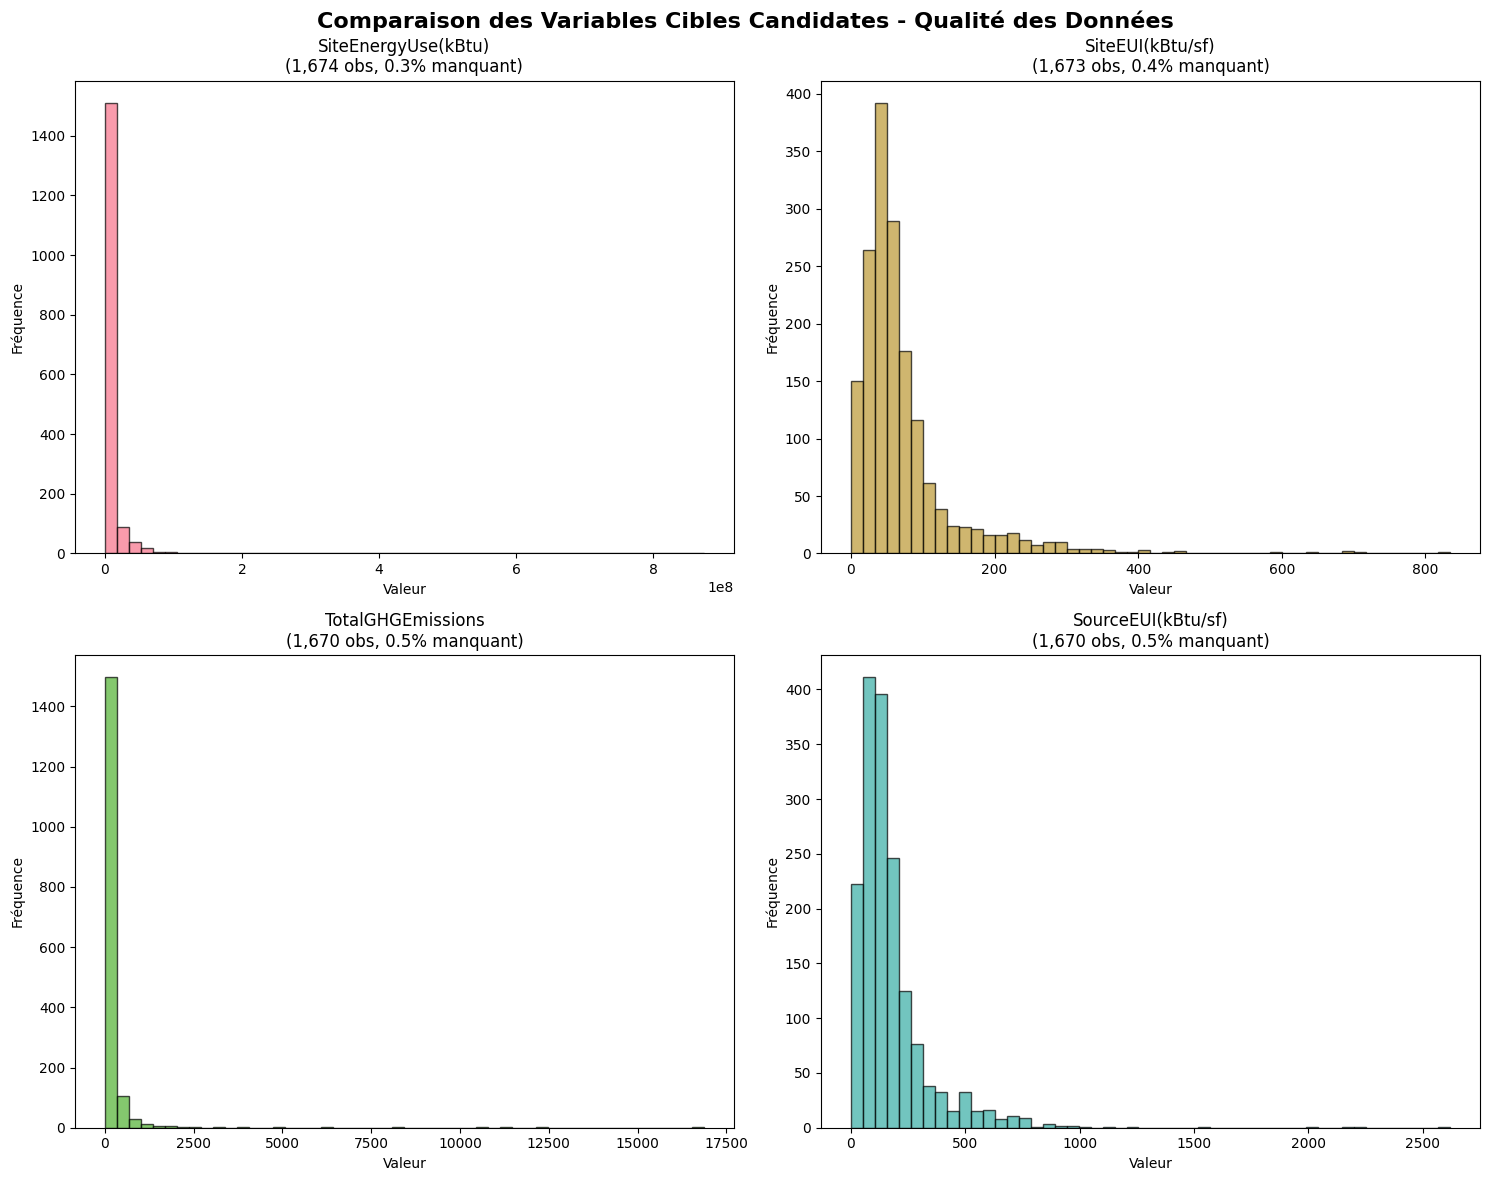


Tableau comparatif de la qualité des données:
           Variable  Observations Manquants (%)   Médiane Écart-type Outliers (%)
SiteEnergyUse(kBtu)          1674          0.3% 2,572,873 30,203,432        11.2%
   SiteEUI(kBtu/sf)          1673          0.4%        51         74         9.5%
  TotalGHGEmissions          1670          0.5%        50        754        10.5%
 SourceEUI(kBtu/sf)          1670          0.5%       131        186         8.4%


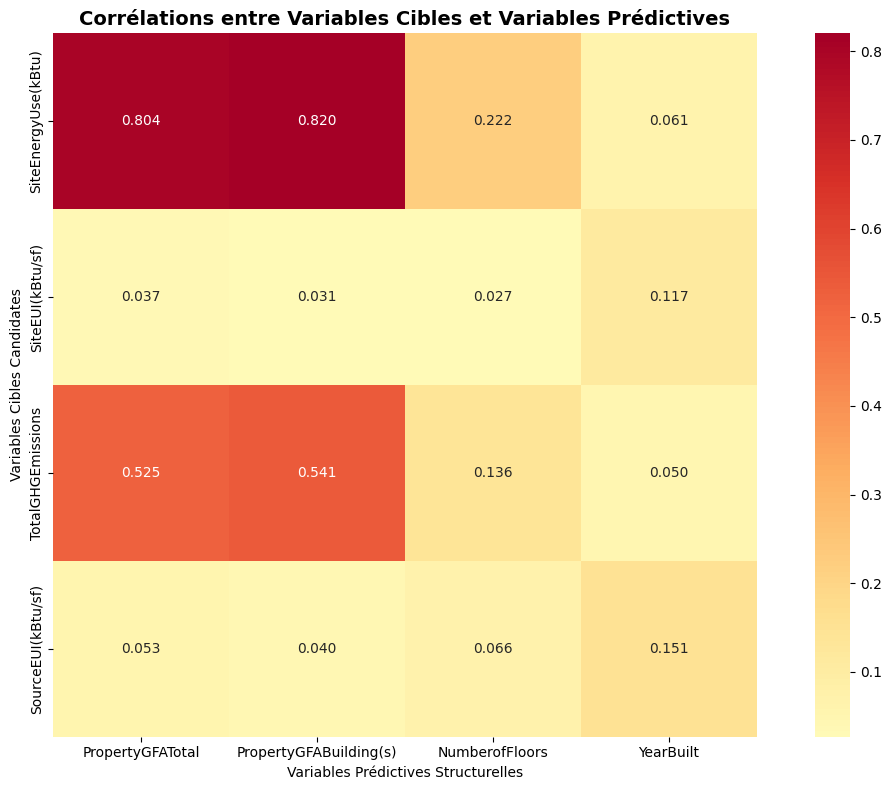

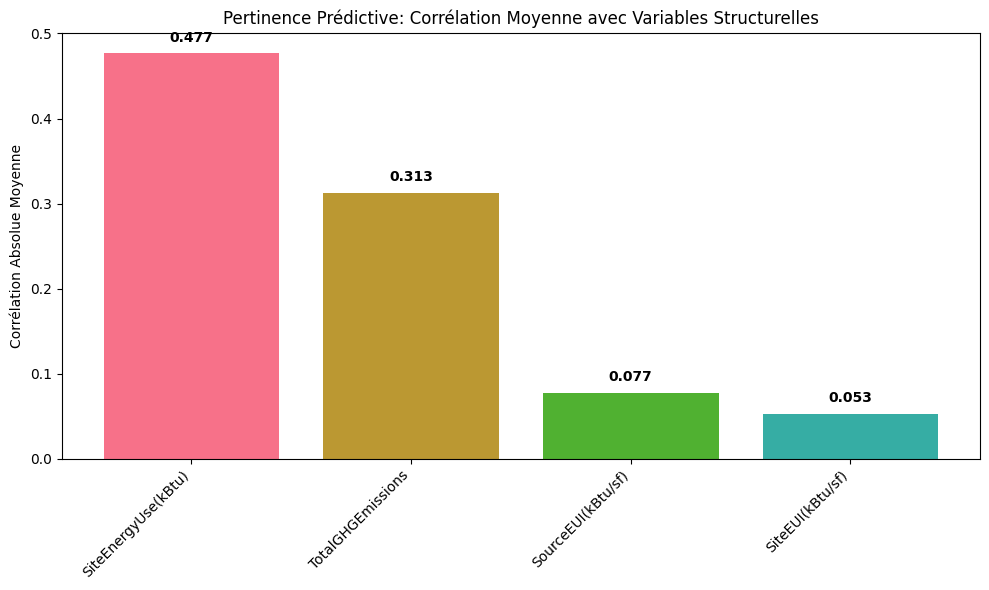

In [21]:
# Justificatif du choix de SiteEnergyUse(kBtu) comme Target

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Variables candidates pour la comparaison
target_candidates = [
    'SiteEnergyUse(kBtu)',
    'SiteEUI(kBtu/sf)', 
    'TotalGHGEmissions',
    'SourceEUI(kBtu/sf)'
]

# Variables prédictives principales supposées d'après l'analyse préliminaire
predictive_vars = [
    'PropertyGFATotal',
    'PropertyGFABuilding(s)', 
    'NumberofFloors',
    'YearBuilt'
]

# Créer 4 graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Comparaison des Variables Cibles Candidates - Qualité des Données', 
             fontsize=16, fontweight='bold')

# Statistiques de qualité pour chaque variable
quality_stats = []

for i, var in enumerate(target_candidates):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    if var in df.columns:
        data = df[var].dropna()
        missing_pct = (df[var].isnull().sum() / len(df)) * 100
        
        # Histogrammes avec distribution
        ax.hist(data, bins=50, alpha=0.7, color=sns.color_palette()[i], edgecolor='black')
        ax.set_title(f'{var}\n({len(data):,} obs, {missing_pct:.1f}% manquant)')
        ax.set_xlabel('Valeur')
        ax.set_ylabel('Fréquence')
        
        # Statistiques pour le tableau
        quality_stats.append({
            'Variable': var,
            'Observations': len(data),
            'Manquants (%)': f"{missing_pct:.1f}%",
            'Médiane': f"{data.median():,.0f}",
            'Écart-type': f"{data.std():,.0f}",
            'Outliers (%)': f"{len(data[(data < data.quantile(0.25) - 1.5*(data.quantile(0.75)-data.quantile(0.25))) | (data > data.quantile(0.75) + 1.5*(data.quantile(0.75)-data.quantile(0.25)))]) / len(data) * 100:.1f}%"
        })
    else:
        ax.text(0.5, 0.5, f'{var}\nNon disponible', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# Tableau comparatif
quality_df = pd.DataFrame(quality_stats)
print("\nTableau comparatif de la qualité des données:")
print(quality_df.to_string(index=False))

# Calculer les corrélations entre variables cibles et prédictives principales supposées
fig, ax = plt.subplots(figsize=(12, 8))

# Matrice de corrélation
correlation_matrix = []
available_targets = [var for var in target_candidates if var in df.columns]
available_predictors = [var for var in predictive_vars if var in df.columns]

corr_data = []
for target in available_targets:
    target_corrs = []
    for predictor in available_predictors:
        # Calculer corrélation en excluant les valeurs manquantes
        mask = df[[target, predictor]].notna().all(axis=1)
        if mask.sum() > 1:
            corr = df.loc[mask, [target, predictor]].corr().iloc[0, 1]
            target_corrs.append(corr)
            corr_data.append({
                'Variable_Cible': target,
                'Variable_Predictive': predictor,
                'Correlation': corr
            })
        else:
            target_corrs.append(np.nan)
    correlation_matrix.append(target_corrs)

# Créer la heatmap
corr_df = pd.DataFrame(correlation_matrix, 
                       index=available_targets, 
                       columns=available_predictors)

sns.heatmap(corr_df, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, ax=ax, fmt='.3f')
ax.set_title('Corrélations entre Variables Cibles et Variables Prédictives', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Variables Cibles Candidates')
ax.set_xlabel('Variables Prédictives Structurelles')

plt.tight_layout()
plt.show()

# Graphique en barres des corrélations moyennes
corr_summary = corr_df.abs().mean(axis=1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(corr_summary)), corr_summary.values, 
              color=sns.color_palette()[:len(corr_summary)])
ax.set_xticks(range(len(corr_summary)))
ax.set_xticklabels(corr_summary.index, rotation=45, ha='right')
ax.set_ylabel('Corrélation Absolue Moyenne')
ax.set_title('Pertinence Prédictive: Corrélation Moyenne avec Variables Structurelles')

# Ajouter les valeurs sur les barres
for i, v in enumerate(corr_summary.values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#### Le choix est donc validé pour la target ***SiteEnergyUse(kBtu)***

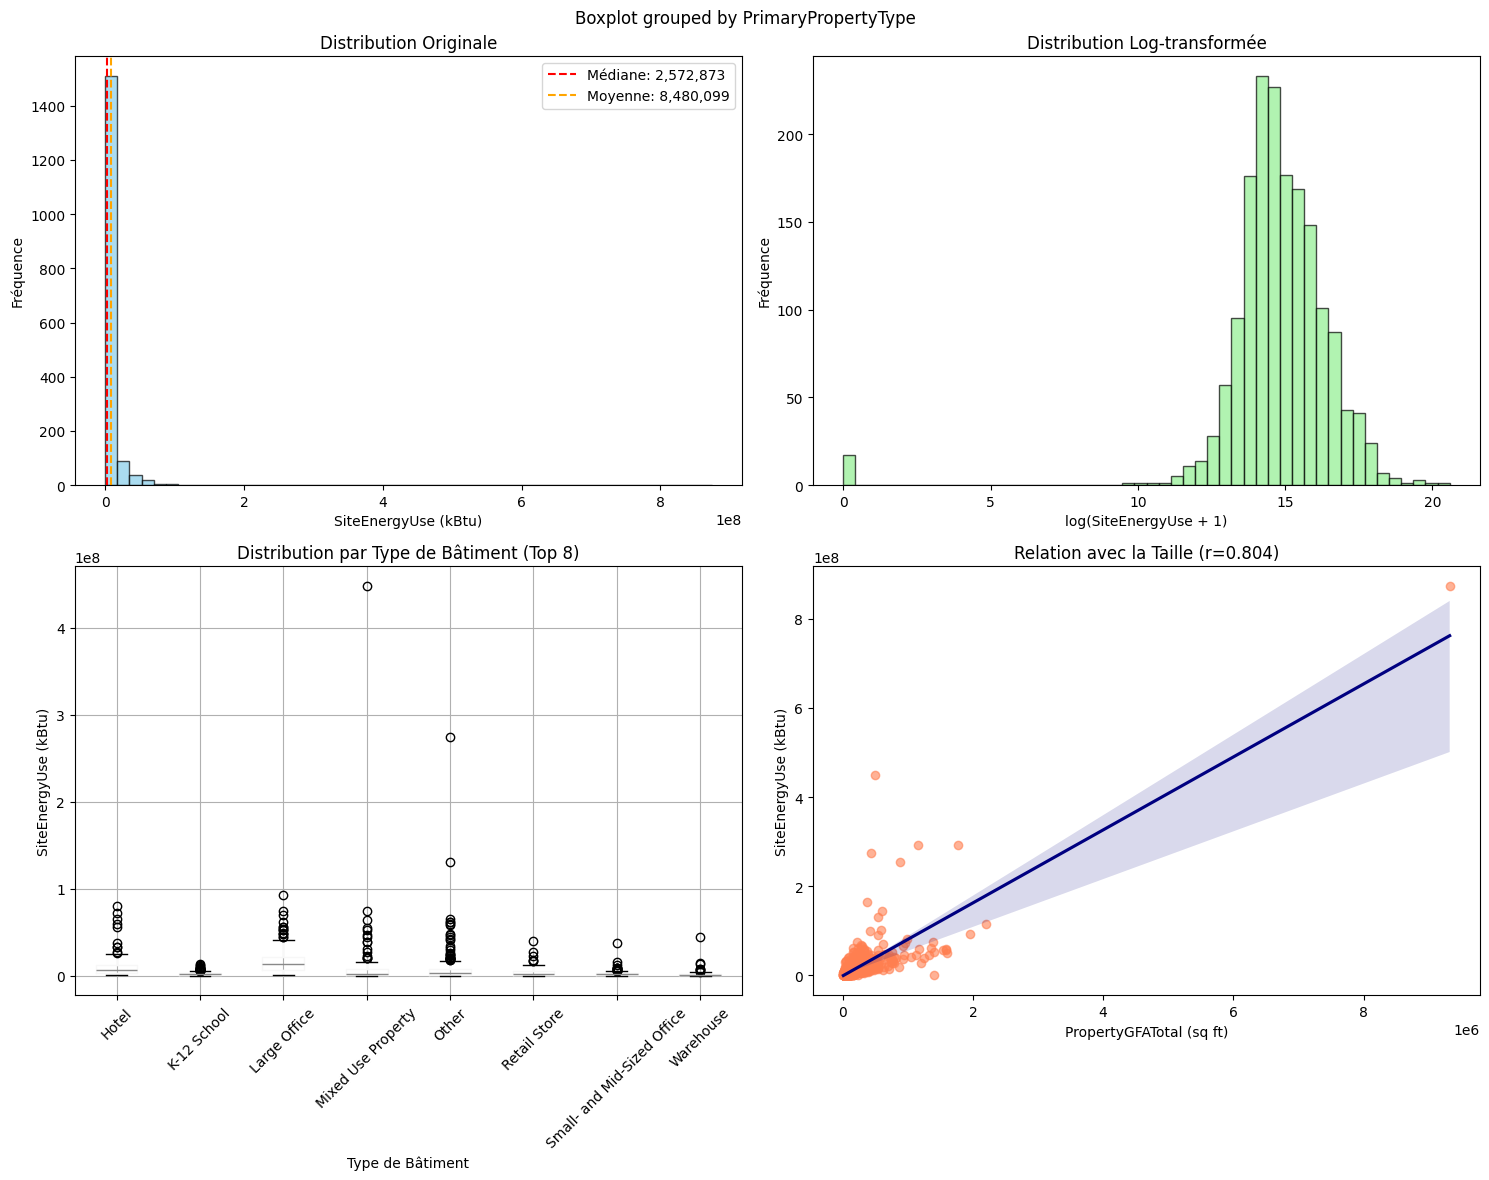

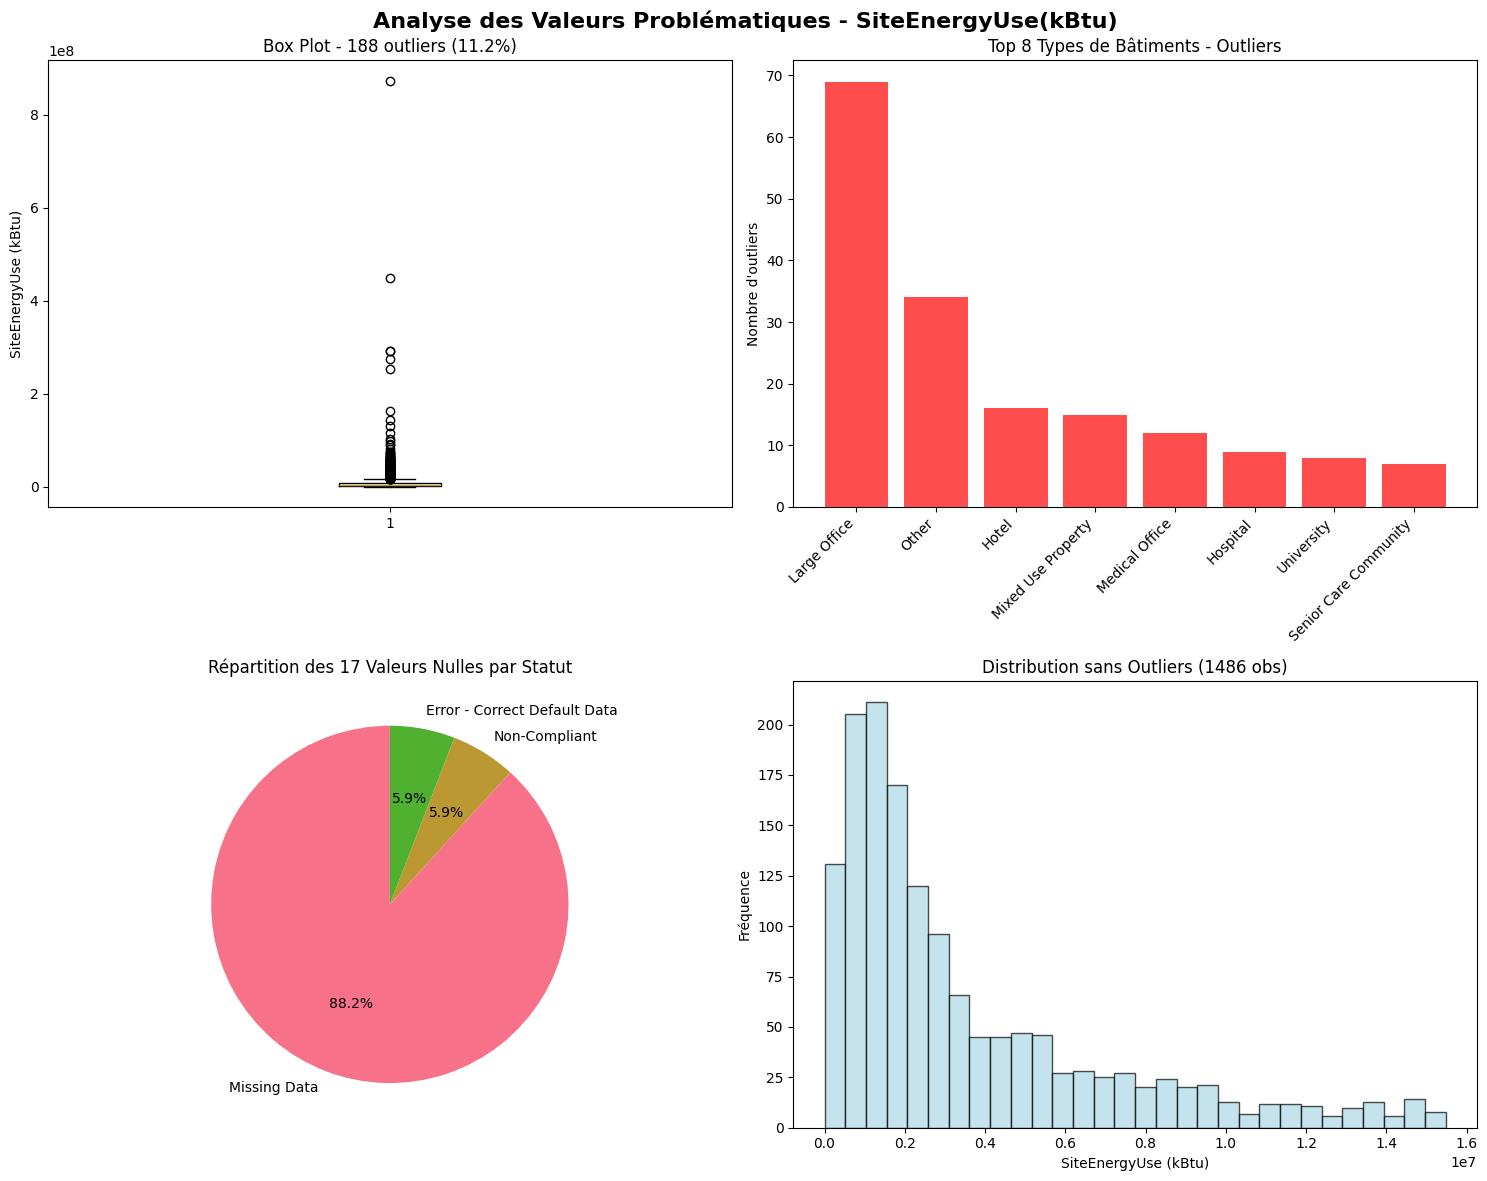


=== RÉSUMÉ STATISTIQUE - SiteEnergyUse(kBtu) ===
Observations totales: 1,679
Valeurs disponibles: 1,674 (99.7%)
Valeurs manquantes: 5 (0.3%)
Valeurs nulles: 17 (1.0%)
Outliers: 188 (11.2%)
Médiane: 2,572,873 kBtu
Moyenne: 8,480,099 kBtu
Maximum: 873,923,712 kBtu
Asymétrie (skewness): 18.02


In [22]:
# définition de la target pour la suite
target = 'SiteEnergyUse(kBtu)'
# définition de target_data (sans les NaN) lorsque les traitements l'exigent
target_data = df[target].dropna()

# Figure avec 4 sous-graphiques pour analyser la distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Analyse Détaillée de {target}', fontsize=16, fontweight='bold')

# 1. Histogramme original
axes[0, 0].hist(target_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution Originale')
axes[0, 0].set_xlabel('SiteEnergyUse (kBtu)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(target_data.median(), color='red', linestyle='--', 
                   label=f'Médiane: {target_data.median():,.0f}')
axes[0, 0].axvline(target_data.mean(), color='orange', linestyle='--', 
                   label=f'Moyenne: {target_data.mean():,.0f}')
axes[0, 0].legend()

# 2. Distribution log-transformée
log_target = np.log1p(target_data)
axes[0, 1].hist(log_target, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution Log-transformée')
axes[0, 1].set_xlabel('log(SiteEnergyUse + 1)')
axes[0, 1].set_ylabel('Fréquence')

# 3. Box plot par type de bâtiment
top_building_types = df['PrimaryPropertyType'].value_counts().head(8).index
df_subset = df[df['PrimaryPropertyType'].isin(top_building_types)]
df_subset.boxplot(column=target, by='PrimaryPropertyType', ax=axes[1, 0], rot=45)
axes[1, 0].set_title('Distribution par Type de Bâtiment (Top 8)')
axes[1, 0].set_xlabel('Type de Bâtiment')
axes[1, 0].set_ylabel('SiteEnergyUse (kBtu)')

# 4. Scatter plot avec PropertyGFATotal
mask = df[[target, 'PropertyGFATotal']].notna().all(axis=1)
sns.regplot(x='PropertyGFATotal', y=target, data=df.loc[mask], 
            ax=axes[1,1], scatter_kws={'color':'coral', 'alpha':0.6}, 
            line_kws={'color':'navy'})
axes[1, 1].set_xlabel('PropertyGFATotal (sq ft)')
axes[1, 1].set_ylabel('SiteEnergyUse (kBtu)')
axes[1, 1].set_title(f'Relation avec la Taille (r={df.loc[mask, [target, "PropertyGFATotal"]].corr().iloc[0,1]:.3f})')

plt.tight_layout()
plt.show()

# Statistiques détaillées sur les outliers
Q1 = target_data.quantile(0.25)
Q3 = target_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target_data[(target_data < lower_bound) | (target_data > upper_bound)]
zero_values = target_data[target_data == 0]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analyse des Valeurs Problématiques - SiteEnergyUse(kBtu)', 
             fontsize=16, fontweight='bold')

# 1. Identification des outliers
axes[0, 0].boxplot(target_data, vert=True)
axes[0, 0].set_title(f'Box Plot - {len(outliers)} outliers ({len(outliers)/len(target_data)*100:.1f}%)')
axes[0, 0].set_ylabel('SiteEnergyUse (kBtu)')

# 2. Distribution des outliers par type de bâtiment
if len(outliers) > 0:
    outlier_buildings = df[df[target].isin(outliers)]
    outlier_counts = outlier_buildings['PrimaryPropertyType'].value_counts().head(8)
    axes[0, 1].bar(range(len(outlier_counts)), outlier_counts.values, 
                   color='red', alpha=0.7)
    axes[0, 1].set_xticks(range(len(outlier_counts)))
    axes[0, 1].set_xticklabels(outlier_counts.index, rotation=45, ha='right')
    axes[0, 1].set_title('Top 8 Types de Bâtiments - Outliers')
    axes[0, 1].set_ylabel('Nombre d\'outliers')

# 3. Valeurs nulles par statut de conformité
zero_buildings = df[df[target] == 0]
if len(zero_buildings) > 0:
    compliance_counts = zero_buildings['ComplianceStatus'].value_counts()
    axes[1, 0].pie(compliance_counts.values, labels=compliance_counts.index, 
                   autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title(f'Répartition des {len(zero_buildings)} Valeurs Nulles par Statut')

# 4. Histogramme sans outliers
clean_data = target_data[(target_data >= lower_bound) & (target_data <= upper_bound)]
axes[1, 1].hist(clean_data, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
axes[1, 1].set_title(f'Distribution sans Outliers ({len(clean_data)} obs)')
axes[1, 1].set_xlabel('SiteEnergyUse (kBtu)')
axes[1, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# Résumé statistique
print(f"\n=== RÉSUMÉ STATISTIQUE - {target} ===")
print(f"Observations totales: {len(df):,}")
print(f"Valeurs disponibles: {len(target_data):,} ({len(target_data)/len(df)*100:.1f}%)")
print(f"Valeurs manquantes: {df[target].isnull().sum():,} ({df[target].isnull().sum()/len(df)*100:.1f}%)")
print(f"Valeurs nulles: {len(zero_values):,} ({len(zero_values)/len(target_data)*100:.1f}%)")
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(target_data)*100:.1f}%)")
print(f"Médiane: {target_data.median():,.0f} kBtu")
print(f"Moyenne: {target_data.mean():,.0f} kBtu")
print(f"Maximum: {target_data.max():,.0f} kBtu")
print(f"Asymétrie (skewness): {stats.skew(target_data):.2f}")

In [23]:
# affichage des 5 plus grands bâtiments et leur consommation :
cols = ['OSEBuildingID', 'PropertyGFATotal', 'SiteEnergyUse(kBtu)']
top2 = df.nlargest(5, 'PropertyGFATotal')[cols]
print(top2)

      OSEBuildingID  PropertyGFATotal  SiteEnergyUse(kBtu)
1639          49967           9320156          873923712.0
981           22062           2200000          114648520.0
545             775           1952220           92937640.0
604             828           1765970          291614432.0
282             422           1605578           49517704.0


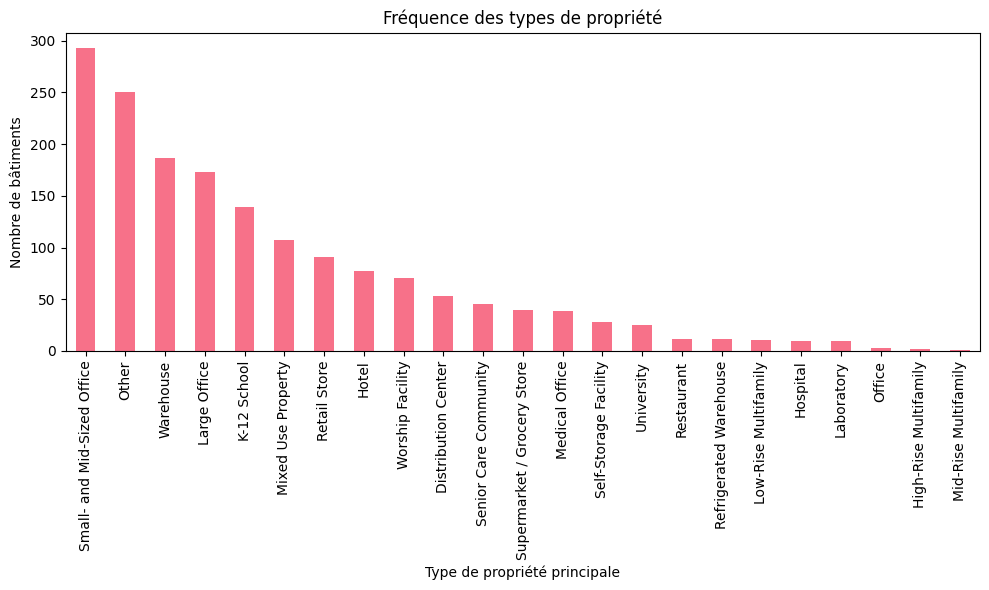

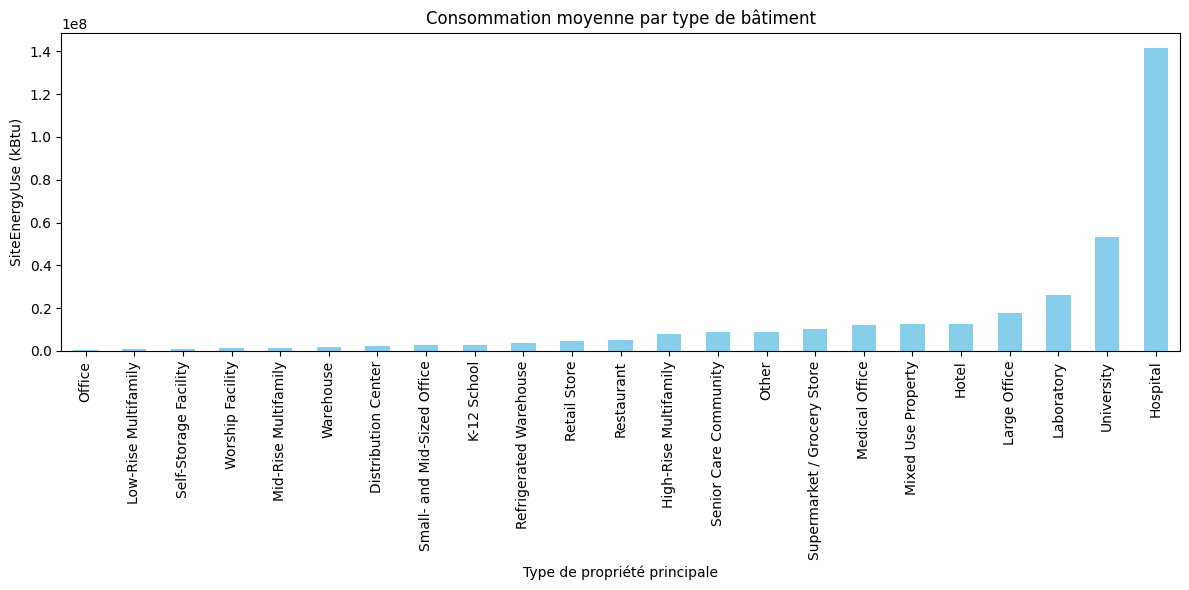

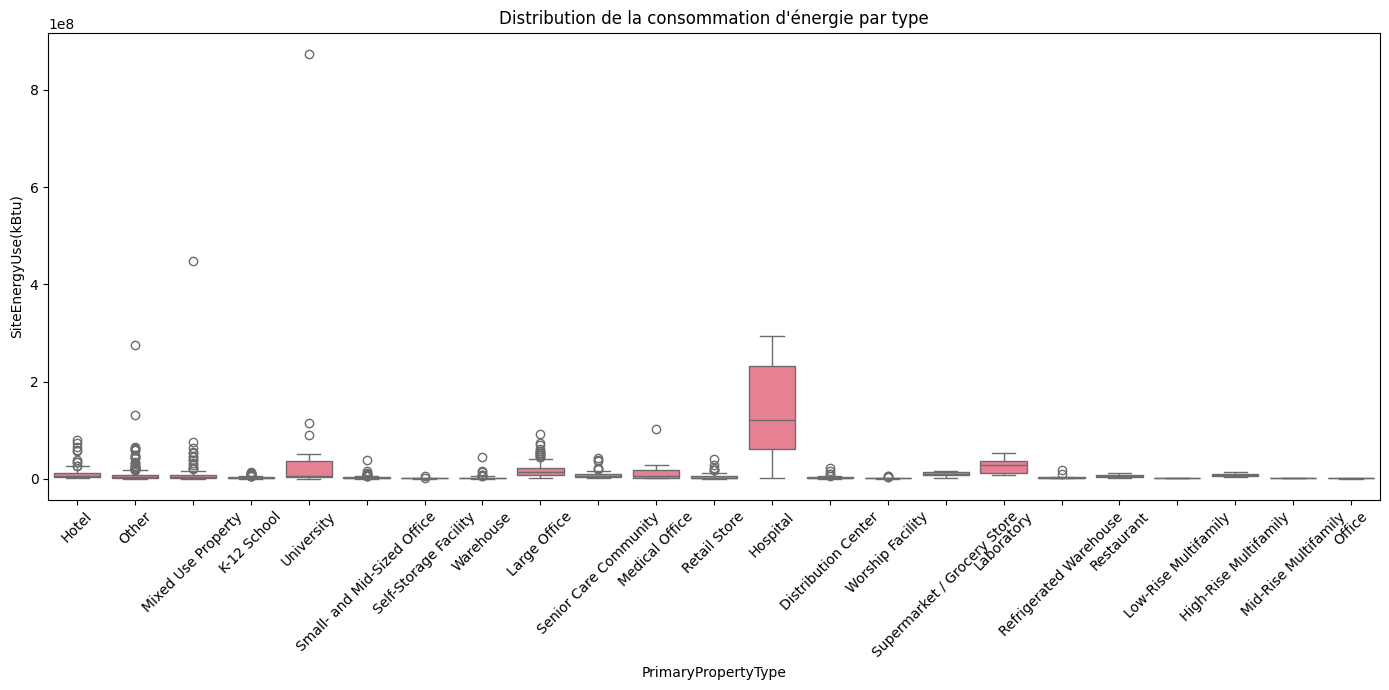

In [27]:
#analyse exploratoire avec encodage catégoriel

# Encodage catégoriel one-hot sur PrimaryPropertyType
df_encoded = pd.get_dummies(df, columns=['PrimaryPropertyType'])

# Comptage des différentes catégories
plt.figure(figsize=(10,6))
df['PrimaryPropertyType'].value_counts().plot(kind='bar')
plt.title('Fréquence des types de propriété')
plt.xlabel('Type de propriété principale')
plt.ylabel('Nombre de bâtiments')
plt.tight_layout()
plt.show()

# Comparaisons de moyenne de la target (SiteEnergyUse) par type
mean_site_energy = df.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)'].mean().sort_values()
plt.figure(figsize=(12,6))
mean_site_energy.plot(kind='bar', color='skyblue')
plt.title('Consommation moyenne par type de bâtiment')
plt.xlabel('Type de propriété principale')
plt.ylabel('SiteEnergyUse (kBtu)')
plt.tight_layout()
plt.show()

# Boxplot consommation par type (distribution)
plt.figure(figsize=(14,7))
sns.boxplot(data=df, x='PrimaryPropertyType', y='SiteEnergyUse(kBtu)')
plt.xticks(rotation=45)
plt.title('Distribution de la consommation d\'énergie par type')
plt.tight_layout()
plt.show()

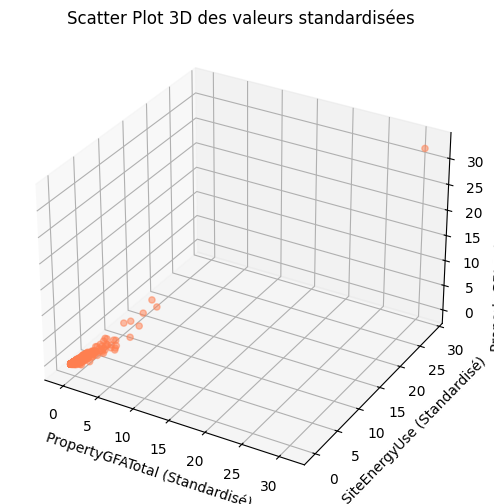

In [33]:
# Standardisation des 3 colonnes
cols = ['SiteEnergyUse(kBtu)', 'PropertyGFATotal', 'PropertyGFABuilding(s)']
scaler = StandardScaler()
df_std = scaler.fit_transform(df[cols])

df['SiteEnergyUse_kBtu_std'] = df_std[:, 0]
df['PropertyGFATotal_std'] = df_std[:, 1]
df['PropertyGFABuilding_s_std'] = df_std[:, 2]

# Sauvegarder dans un nouveau fichier CSV
df.to_csv('../data/processed/building_consumption_std.csv', index=False)

# Création du scatter plot 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df['PropertyGFATotal_std'],
    df['SiteEnergyUse_kBtu_std'],
    df['PropertyGFABuilding_s_std'],
    alpha=0.5,
    c='coral'
)
ax.set_xlabel('PropertyGFATotal (Standardisé)')
ax.set_ylabel('SiteEnergyUse (Standardisé)')
ax.set_zlabel('PropertyGFABuilding(s) (Standardisé)')
ax.set_title('Scatter Plot 3D des valeurs standardisées')
plt.show()

# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE